## Step 1: Install Required Libraries


In [1]:
%pip install -q duckdb huggingface_hub


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2: Enter Hugging Face Token

In [ ]:
import getpass

HF_TOKEN = getpass.getpass("Enter your Hugging Face Token: ")

 Connect to the FlyRank Dataset

Configure Hugging Face authentication and define the dataset path for direct access.

In [ ]:
import duckdb

con = duckdb.connect()

con.execute(f"""
CREATE SECRET (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

rel = "hf://datasets/FlyRank/internship-warehouse"

print("Connected successfully!")

Connected successfully!


Explore Dataset Structure

List the available Parquet files to understand the dataset tables and folder structure.

In [ ]:
result = con.sql(f"""
SELECT *
FROM glob('{rel}/**/*.parquet')
LIMIT 20
""")

print(result)

┌────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                                                  file                                                  │
│                                                varchar                                                 │
├────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ hf://datasets/FlyRank/internship-warehouse/dim_clients.parquet                                         │
│ hf://datasets/FlyRank/internship-warehouse/dim_content.parquet                                         │
│ hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-01/data_0.parquet │
│ hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-02/data_0.parquet │
│ hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-03/data_0.parquet │
│ hf://datasets/FlyRank/internship-wa

 Identify the Main Performance Data

The dataset contains a daily content performance table organized by monthly partitions. This table will be used for the capstone analysis.

In [ ]:
con.sql(f"""
SELECT COUNT(*)
FROM read_parquet(
    '{rel}/fact_content_daily_performance/**/*.parquet'
)
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│     78835655 │
└──────────────┘



In [ ]:
df = con.sql(f"""
SELECT *
FROM read_parquet(
    '{rel}/fact_content_daily_performance/**/*.parquet'
)
LIMIT 10
""").df()

df

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,2025-01
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,...,0,0,0,0,0,0,0,0,0,2025-01
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,...,0,0,0,0,0,0,0,0,0,2025-01
5,2025-01-27,client_9958f0a7ae1df715,content_c782fa8abd4fce5e,True,True,True,False,21,0,1050,...,0,0,0,0,0,0,0,0,0,2025-01
6,2025-01-27,client_9958f0a7ae1df715,content_ae5e5fd6edff550f,True,True,True,False,13,0,127,...,0,0,0,0,0,0,0,0,0,2025-01
7,2025-01-27,client_9958f0a7ae1df715,content_a64143f6e4a21ffe,True,True,True,False,29,0,356,...,0,0,0,0,0,0,0,0,0,2025-01
8,2025-01-27,client_9958f0a7ae1df715,content_e281674658070602,True,True,True,False,5,0,103,...,0,0,0,0,0,0,0,0,0,2025-01
9,2025-01-27,client_9958f0a7ae1df715,content_658f53fa439c66ca,True,True,True,False,8,0,304,...,0,0,0,0,0,0,0,0,0,2025-01


In [ ]:
con.sql(f"""
DESCRIBE
SELECT *
FROM read_parquet(
    '{rel}/fact_content_daily_performance/**/*.parquet'
)
""").df()

,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


# Capstone Continuation — Refresh / Content Opportunity Scoring

**Research question:** Can historical search and engagement signals identify content that is likely to decline in the following month, so content teams can prioritize pages for review?

**Decision supported:** Which anonymized content items should be reviewed first?

This notebook continues `Capstone_Project.ipynb` and reuses its existing `con`, `rel`, and `HF_TOKEN` variables.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

pd.set_option("display.max_columns", 100)
PERFORMANCE_GLOB = f"{rel}/fact_content_daily_performance/**/*.parquet"

## 1. Verify monthly coverage

Read the actual month coverage before choosing train/validation/test periods.

In [ ]:
months = con.sql(f'''
    SELECT month,
           COUNT(*) AS rows,
           COUNT(DISTINCT content_hash_id) AS contents
    FROM read_parquet('{PERFORMANCE_GLOB}')
    GROUP BY month
    ORDER BY month
''').df()

display(months)
print("Month range:", months["month"].min(), "to", months["month"].max())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,rows,contents
0,2025-01,1297,476
1,2025-02,75985,5903
2,2025-03,167859,10374
3,2025-04,285114,13046
4,2025-05,349923,14887
5,2025-06,329201,16399
6,2025-07,469794,27945
7,2025-08,704962,37204
8,2025-09,845813,53127
9,2025-10,2165471,110339


Month range: 2025-01 to 2026-06


## 2. Aggregate daily data to content-month level

The modeling unit is one anonymized content item in one month.

In [ ]:
monthly = con.sql(f'''
    SELECT
        content_hash_id,
        month,
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        AVG(gsc_avg_position) AS avg_position,
        SUM(ga4_pageviews) AS pageviews,
        SUM(ga4_sessions) AS sessions,
        SUM(ga4_users) AS users,
        SUM(ga4_engaged_sessions) AS engaged_sessions,
        SUM(ga4_total_engagement_sec) AS engagement_seconds,
        SUM(sessions_organic) AS organic_sessions,
        SUM(sessions_direct) AS direct_sessions,
        SUM(sessions_referral) AS referral_sessions,
        SUM(sessions_social) AS social_sessions,
        SUM(sessions_paid) AS paid_sessions,
        SUM(sessions_ai) AS ai_sessions,
        SUM(scroll_events) AS scroll_events
    FROM read_parquet('{PERFORMANCE_GLOB}')
    GROUP BY content_hash_id, month
    ORDER BY month, content_hash_id
''').df()

monthly["month"] = pd.to_datetime(monthly["month"])
print("Content-month rows:", len(monthly))
display(monthly.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Content-month rows: 2871202


,content_hash_id,month,impressions,clicks,avg_position,pageviews,sessions,users,engaged_sessions,engagement_seconds,organic_sessions,direct_sessions,referral_sessions,social_sessions,paid_sessions,ai_sessions,scroll_events
0,content_0089cb2664140c0a,2025-01-01,7.0,0.0,28.666667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,content_01d48890af12916f,2025-01-01,1.0,0.0,11.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,content_0208673d5d06fe3f,2025-01-01,4.0,0.0,8.833333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,content_0217be03126aa7a5,2025-01-01,119.0,0.0,6.422527,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,content_02a606212c01ce89,2025-01-01,6.0,0.0,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Create derived metrics

In [ ]:
def safe_divide(a, b):
    return a / b.replace(0, np.nan)

monthly["ctr"] = safe_divide(monthly["clicks"], monthly["impressions"])
monthly["engagement_rate"] = safe_divide(monthly["engaged_sessions"], monthly["sessions"])
monthly["avg_engagement_sec"] = safe_divide(monthly["engagement_seconds"], monthly["sessions"])
monthly["scroll_rate"] = safe_divide(monthly["scroll_events"], monthly["pageviews"])
monthly = monthly.replace([np.inf, -np.inf], np.nan)

display(monthly[
    ["impressions", "clicks", "ctr", "avg_position", "sessions",
     "organic_sessions", "engaged_sessions", "engagement_rate",
     "avg_engagement_sec", "scroll_rate", "ai_sessions"]
].describe().T)

,count,mean,std,min,25%,50%,75%,max
impressions,2871202.0,614.209652,3410.774882,0.0,0.000000,1.000000,138.000000,799358.0
clicks,2871202.0,2.243255,124.503639,0.0,0.000000,0.000000,0.000000,152170.0
ctr,1546456.0,0.004926,0.035492,0.0,0.000000,0.000000,0.002334,1.0
avg_position,1546455.0,18.065847,19.210393,0.0,5.666667,9.897436,23.937878,633.0
sessions,1920446.0,4.328716,264.355916,0.0,0.000000,0.000000,1.000000,235840.0
organic_sessions,1920446.0,2.714680,108.988260,0.0,0.000000,0.000000,0.000000,103297.0
engaged_sessions,1920446.0,0.146421,4.193815,0.0,0.000000,0.000000,0.000000,1277.0
engagement_rate,578276.0,0.032833,0.121016,0.0,0.000000,0.000000,0.000000,1.0
avg_engagement_sec,578276.0,5.365748,29.519211,0.0,0.000000,0.000000,1.000000,3235.0
scroll_rate,578225.0,0.182854,0.319187,0.0,0.000000,0.000000,0.222222,4.0


## 4. Exploratory analysis

,month,content_count,impressions,clicks,organic_sessions,sessions,ai_sessions
0,2025-01-01,476,13853.0,108.0,0.0,0.0,0.0
1,2025-02-01,5903,1195015.0,7823.0,0.0,0.0,0.0
2,2025-03-01,10374,3847103.0,26138.0,0.0,0.0,0.0
3,2025-04-01,13046,8843940.0,52974.0,0.0,0.0,0.0
4,2025-05-01,14887,14454515.0,70374.0,0.0,0.0,0.0
5,2025-06-01,16399,16930659.0,70245.0,0.0,0.0,0.0
6,2025-07-01,27945,20298448.0,84676.0,0.0,0.0,0.0
7,2025-08-01,37204,29289942.0,119373.0,0.0,0.0,0.0
8,2025-09-01,53127,37726329.0,176130.0,0.0,0.0,0.0
9,2025-10-01,110339,55073098.0,274631.0,34009.0,22210.0,422.0


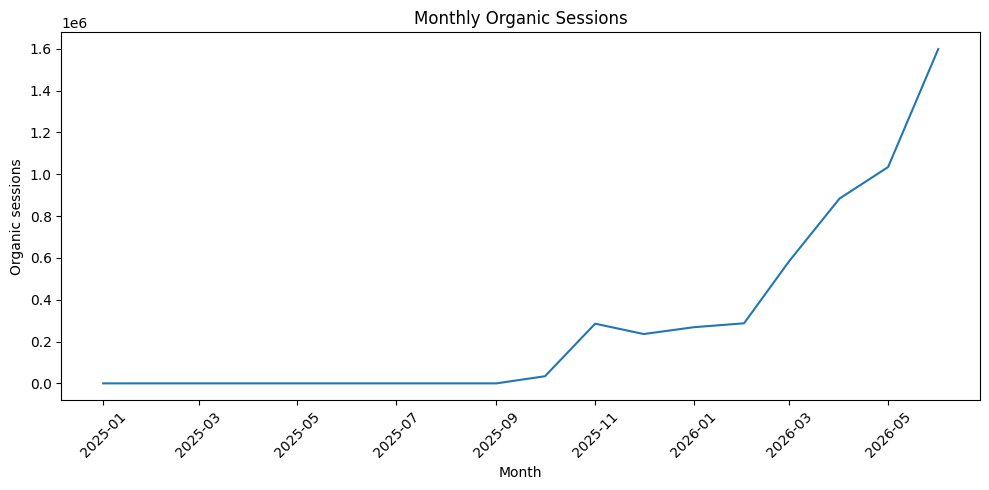

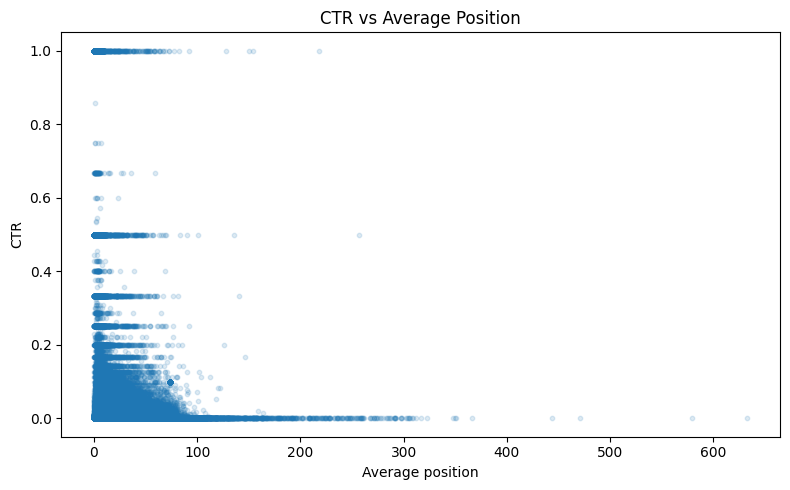

In [ ]:
monthly_summary = (
    monthly.groupby("month")
    .agg(
        content_count=("content_hash_id", "nunique"),
        impressions=("impressions", "sum"),
        clicks=("clicks", "sum"),
        organic_sessions=("organic_sessions", "sum"),
        sessions=("sessions", "sum"),
        ai_sessions=("ai_sessions", "sum")
    )
    .reset_index()
)

display(monthly_summary)
monthly_summary.to_csv("capstone_monthly_summary.csv", index=False)

plt.figure(figsize=(10, 5))
plt.plot(monthly_summary["month"], monthly_summary["organic_sessions"])
plt.title("Monthly Organic Sessions")
plt.xlabel("Month")
plt.ylabel("Organic sessions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("capstone_monthly_organic_sessions.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(monthly["avg_position"], monthly["ctr"], alpha=0.15, s=10)
plt.xlabel("Average position")
plt.ylabel("CTR")
plt.title("CTR vs Average Position")
plt.tight_layout()
plt.savefig("capstone_ctr_vs_average_position.png", dpi=200, bbox_inches="tight")
plt.show()


## 5. Build previous-month features

All prediction features must be available before the outcome month. We therefore shift each content item's previous-month metrics into the current row.

In [ ]:
monthly = monthly.sort_values(["content_hash_id", "month"]).copy()

base_feature_cols = [
    "impressions", "clicks", "ctr", "avg_position",
    "pageviews", "sessions", "users", "engaged_sessions",
    "engagement_seconds", "organic_sessions", "direct_sessions",
    "referral_sessions", "social_sessions", "paid_sessions",
    "ai_sessions", "scroll_events", "engagement_rate",
    "avg_engagement_sec", "scroll_rate"
]

for col in base_feature_cols:
    monthly[f"prev_{col}"] = monthly.groupby("content_hash_id")[col].shift(1)

for col in ["organic_sessions", "impressions", "clicks", "sessions"]:
    monthly[f"{col}_mom_1m"] = (
        monthly.groupby("content_hash_id")[col].shift(1)
        / monthly.groupby("content_hash_id")[col].shift(2).replace(0, np.nan)
        - 1
    )

display(monthly[
    ["content_hash_id", "month", "prev_organic_sessions",
     "organic_sessions", "organic_sessions_mom_1m"]
].head(15))

,content_hash_id,month,prev_organic_sessions,organic_sessions,organic_sessions_mom_1m
6379,content_000005d4ced12088,2025-03-01,NaN,0.0,NaN
16753,content_000005d4ced12088,2025-04-01,0.0,0.0,NaN
29799,content_000005d4ced12088,2025-05-01,0.0,0.0,NaN
44686,content_000005d4ced12088,2025-06-01,0.0,0.0,NaN
61085,content_000005d4ced12088,2025-07-01,0.0,0.0,NaN
89030,content_000005d4ced12088,2025-08-01,0.0,0.0,NaN
126234,content_000005d4ced12088,2025-09-01,0.0,0.0,NaN
179361,content_000005d4ced12088,2025-10-01,0.0,0.0,NaN
289700,content_000005d4ced12088,2025-11-01,0.0,0.0,NaN
541084,content_000005d4ced12088,2025-12-01,0.0,0.0,NaN


## 6. Define the decline target

A content item is positive when organic sessions decline by **20% or more** versus the previous month.

In [ ]:
monthly["organic_change"] = (
    monthly["organic_sessions"]
    / monthly["prev_organic_sessions"].replace(0, np.nan)
) - 1

DECLINE_THRESHOLD = -0.20

monthly["declined_next_month"] = (
    monthly["organic_change"] <= DECLINE_THRESHOLD
).astype("Int64")

model_df = monthly[
    monthly["prev_organic_sessions"].notna()
    & (monthly["prev_impressions"] >= 100)
    & (monthly["prev_sessions"] >= 10)
    & monthly["declined_next_month"].notna()
].copy()

print("Model rows:", len(model_df))
print("Decline rate:", round(float(model_df["declined_next_month"].mean()), 4))
display(model_df["declined_next_month"].value_counts(dropna=False))

Model rows: 97692
Decline rate: 0.4382


,count
declined_next_month,
0,54883
1,42809


## 7. Time-aware train / validation / test split

- Train: through March 2026
- Validation: April 2026
- Test: May–June 2026

The assertions prevent silently using an invalid period.

In [ ]:
required = {"2026-03", "2026-04", "2026-05", "2026-06"}
available = set(model_df["month"].dt.to_period("M").astype(str))
missing = sorted(required - available)

if missing:
    raise ValueError(
        f"Missing expected evaluation months: {missing}. "
        "Inspect the coverage table and adjust only after verification."
    )

train = model_df[model_df["month"] <= "2026-03-01"].copy()
validation = model_df[model_df["month"] == "2026-04-01"].copy()
test = model_df[model_df["month"] >= "2026-05-01"].copy()

print("Train:", len(train), train["month"].min(), "to", train["month"].max())
print("Validation:", len(validation), validation["month"].min(), "to", validation["month"].max())
print("Test:", len(test), test["month"].min(), "to", test["month"].max())

Train: 19621 2025-11-01 00:00:00 to 2026-03-01 00:00:00
Validation: 20613 2026-04-01 00:00:00 to 2026-04-01 00:00:00
Test: 57458 2026-05-01 00:00:00 to 2026-06-01 00:00:00


## 8. Leakage audit

In [ ]:
features = [
    "prev_impressions", "prev_clicks", "prev_ctr", "prev_avg_position",
    "prev_pageviews", "prev_sessions", "prev_users", "prev_engaged_sessions",
    "prev_engagement_seconds", "prev_organic_sessions",
    "prev_direct_sessions", "prev_referral_sessions", "prev_social_sessions",
    "prev_paid_sessions", "prev_ai_sessions", "prev_scroll_events",
    "prev_engagement_rate", "prev_avg_engagement_sec", "prev_scroll_rate",
    "organic_sessions_mom_1m", "impressions_mom_1m",
    "clicks_mom_1m", "sessions_mom_1m"
]

for forbidden in ["organic_sessions", "clicks", "impressions", "sessions", "engaged_sessions"]:
    assert forbidden not in features, f"Potential current-month leakage: {forbidden}"

print("Leakage audit passed.")
print("Feature count:", len(features))

Leakage audit passed.
Feature count: 23


## 9. Baseline — predict no decline

In [ ]:
y_train = train["declined_next_month"].astype(int)
y_val = validation["declined_next_month"].astype(int)
y_test = test["declined_next_month"].astype(int)

baseline_test_pred = np.zeros(len(test), dtype=int)

baseline_test = {
    "precision": precision_score(y_test, baseline_test_pred, zero_division=0),
    "recall": recall_score(y_test, baseline_test_pred, zero_division=0),
    "f1": f1_score(y_test, baseline_test_pred, zero_division=0)
}

display(pd.DataFrame([baseline_test], index=["No-decline baseline"]).round(4))

,precision,recall,f1
No-decline baseline,0.0,0.0,0.0


## 10. Train logistic regression

In [ ]:
X_train = train[features]
X_val = validation[features]
X_test = test[features]

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(X_train, y_train)

val_prob = model.predict_proba(X_val)[:, 1]
test_prob = model.predict_proba(X_test)[:, 1]

val_pred = (val_prob >= 0.50).astype(int)
test_pred = (test_prob >= 0.50).astype(int)

## 11. Evaluate baseline vs model

In [ ]:
def metrics(y, pred, prob):
    return {
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "roc_auc": roc_auc_score(y, prob)
    }

model_val = metrics(y_val, val_pred, val_prob)
model_test = metrics(y_test, test_pred, test_prob)

results = pd.DataFrame([
    {"model": "No-decline baseline", "split": "Test",
     **baseline_test, "roc_auc": np.nan},
    {"model": "Logistic Regression", "split": "Validation", **model_val},
    {"model": "Logistic Regression", "split": "Test", **model_test}
])

display(results.round(4))
results.to_csv("capstone_model_evaluation_results.csv", index=False)
print("Evaluation results saved to capstone_model_evaluation_results.csv")

print("Test confusion matrix:")
print(confusion_matrix(y_test, test_pred))


,model,split,precision,recall,f1,roc_auc
0,No-decline baseline,Test,0.0000,0.0000,0.0000,NaN
1,Logistic Regression,Validation,0.3769,0.6458,0.4760,0.5348
2,Logistic Regression,Test,0.4967,0.2927,0.3684,0.5409


Test confusion matrix:
[[24123  7626]
 [18183  7526]]


## 11A. Confusion matrix and diagnostic charts

A confusion matrix shows the count of correctly and incorrectly classified decline cases on the untouched test period. ROC and precision-recall curves show performance across decision thresholds rather than only the selected 0.50 cutoff.


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, precision_recall_curve, average_precision_score

# 1. Confusion Matrix Table & Visualization
cm = confusion_matrix(y_test, test_pred)
cm_table = pd.DataFrame(
    cm,
    index=["Actual: no decline", "Actual: decline"],
    columns=["Predicted: no decline", "Predicted: decline"]
)
display(cm_table)

# Standalone Confusion Matrix Graph
fig, ax = plt.subplots(figsize=(6.5, 5.5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No decline", "Decline"]
)
disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
ax.set_title("Test-Set Confusion Matrix (Logistic Regression)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("capstone_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Standalone ROC Curve Graph
fpr, tpr, thresholds = roc_curve(y_test, test_prob)
roc_auc = model_test['roc_auc']

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(fpr, tpr, color="#1f77b4", lw=2.5, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="#d62728", lw=1.5, linestyle="--", label="Random Chance (AUC = 0.500)")
ax.fill_between(fpr, tpr, alpha=0.15, color="#1f77b4")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
ax.set_ylabel("True Positive Rate (Recall / Sensitivity)", fontsize=11)
ax.set_title("Receiver Operating Characteristic (ROC) Curve - Test Set", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", frameon=True, fontsize=10)
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.savefig("capstone_roc_curve.png", dpi=300, bbox_inches="tight")
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Precision-Recall Curve & Diagnostic Dashboard
precision, recall, _ = precision_recall_curve(y_test, test_prob)
ap = average_precision_score(y_test, test_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, color="#1f77b4", lw=2, label=f"ROC AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
axes[0].set_title("Test ROC Curve", fontweight="bold")
axes[0].set_xlabel("False-Positive Rate")
axes[0].set_ylabel("True-Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle=":", alpha=0.5)

axes[1].plot(recall, precision, color="#2ca02c", lw=2, label=f"Average Precision = {ap:.3f}")
axes[1].set_title("Test Precision-Recall Curve", fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")
axes[1].grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("capstone_test_diagnostic_curves.png", dpi=300, bbox_inches="tight")
plt.show()

# 4. Save results and predictions to CSV
cm_table.to_csv("capstone_confusion_matrix.csv")
cm_table.to_csv("confusion_matrix.csv")

test_predictions_df = test[["content_hash_id", "month", "declined_next_month"]].copy()
test_predictions_df["predicted_decline"] = test_pred
test_predictions_df["decline_probability"] = test_prob.round(4)
test_predictions_df.to_csv("capstone_test_predictions.csv", index=False)

print("All evaluation graphs and data have been successfully saved:")
print(" - capstone_confusion_matrix.png / confusion_matrix.png")
print(" - capstone_roc_curve.png / roc_curve.png")
print(" - capstone_test_diagnostic_curves.png")
print(" - capstone_confusion_matrix.csv / confusion_matrix.csv")
print(" - capstone_test_predictions.csv")
print(" - capstone_model_evaluation_results.csv")


## 12. Feature importance

,feature,coefficient,abs_coefficient
0,prev_pageviews,-1.708341,1.708341
1,prev_organic_sessions,1.432554,1.432554
2,prev_clicks,-0.925223,0.925223
3,prev_sessions,0.924777,0.924777
4,prev_paid_sessions,0.713699,0.713699
5,prev_scroll_rate,0.407567,0.407567
6,prev_users,0.352424,0.352424
7,prev_scroll_events,0.295768,0.295768
8,prev_engagement_seconds,-0.273827,0.273827
9,organic_sessions_mom_1m,0.156425,0.156425


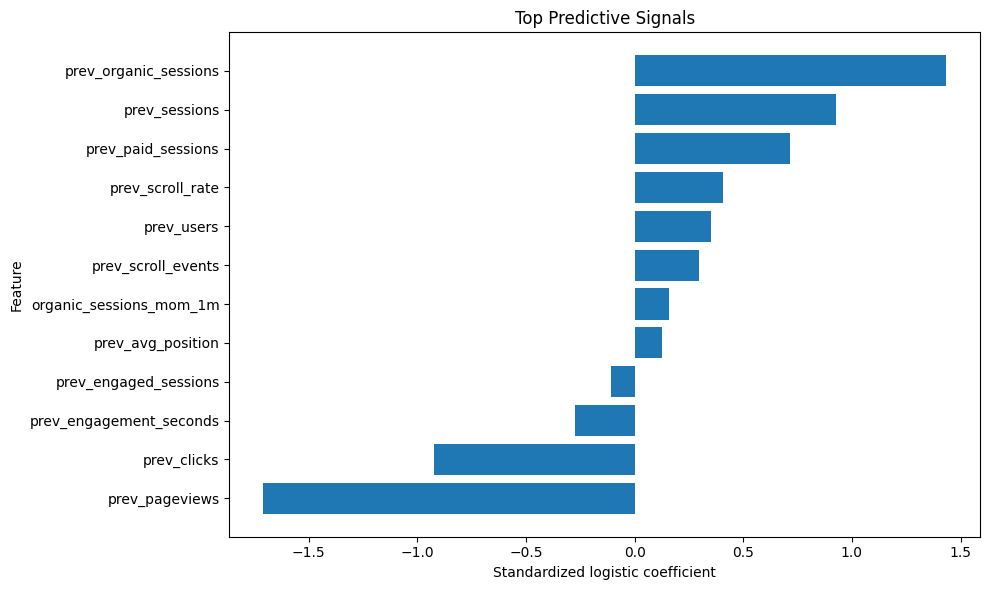

In [ ]:
importance = pd.DataFrame({
    "feature": features,
    "coefficient": model.named_steps["classifier"].coef_[0]
})

importance["abs_coefficient"] = importance["coefficient"].abs()
importance = importance.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

importance.to_csv("capstone_feature_importance.csv", index=False)
display(importance.head(15))

top = importance.head(12).sort_values("coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top["feature"], top["coefficient"])
plt.xlabel("Standardized logistic coefficient")
plt.ylabel("Feature")
plt.title("Top Predictive Signals")
plt.tight_layout()
plt.savefig("capstone_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()


## 13. Ranked recommendation engine

In [ ]:
recommendations = test[
    ["content_hash_id", "month", "prev_organic_sessions",
     "prev_impressions", "prev_ctr", "prev_avg_position",
     "prev_engagement_rate", "prev_ai_sessions"]
].copy()

recommendations["decline_probability"] = test_prob

def action_from_probability(p):
    if p >= 0.75:
        return "HIGH PRIORITY - REVIEW"
    if p >= 0.50:
        return "MEDIUM PRIORITY - MONITOR"
    return "LOW PRIORITY - PROTECT"

def reason_code(row):
    reasons = []
    if pd.notna(row["prev_ctr"]) and row["prev_ctr"] < 0.02:
        reasons.append("Low CTR")
    if pd.notna(row["prev_avg_position"]) and row["prev_avg_position"] > 10:
        reasons.append("Weak average position")
    if pd.notna(row["prev_impressions"]) and row["prev_impressions"] >= 1000:
        reasons.append("Meaningful search visibility")
    if pd.notna(row["prev_engagement_rate"]) and row["prev_engagement_rate"] < 0.50:
        reasons.append("Lower engagement rate")
    return "; ".join(reasons) if reasons else "Model risk score"

recommendations["action"] = recommendations["decline_probability"].apply(action_from_probability)
recommendations["reason_code"] = recommendations.apply(reason_code, axis=1)
recommendations = recommendations.sort_values("decline_probability", ascending=False).reset_index(drop=True)
recommendations["rank"] = np.arange(1, len(recommendations) + 1)

top20 = recommendations.head(20)
display(top20)

,content_hash_id,month,prev_organic_sessions,prev_impressions,prev_ctr,prev_avg_position,prev_engagement_rate,prev_ai_sessions,decline_probability,action,reason_code,rank
0,content_fc0e11252376bb58,2026-06-01,12.0,4499.0,0.002667,2.715471,0.000178,0.0,1.000000,HIGH PRIORITY - REVIEW,Low CTR; Meaningful search visibility; Lower e...,1
1,content_d8a9f27682068c84,2026-05-01,97.0,1324.0,0.010574,13.633376,0.013504,0.0,1.000000,HIGH PRIORITY - REVIEW,Low CTR; Weak average position; Meaningful sea...,2
2,content_d8a9f27682068c84,2026-06-01,148.0,1908.0,0.014151,11.351896,0.013748,0.0,1.000000,HIGH PRIORITY - REVIEW,Low CTR; Weak average position; Meaningful sea...,3
3,content_95400d53c15c4d85,2026-06-01,2.0,2305.0,0.001735,8.874741,0.000462,0.0,1.000000,HIGH PRIORITY - REVIEW,Low CTR; Meaningful search visibility; Lower e...,4
4,content_5fa2737c68998c2e,2026-05-01,1862.0,107813.0,0.012679,4.334339,0.008488,0.0,1.000000,HIGH PRIORITY - REVIEW,Low CTR; Meaningful search visibility; Lower e...,5
5,content_f5d08f600fec17d6,2026-05-01,1550.0,51847.0,0.021698,7.909258,0.013321,0.0,0.999999,HIGH PRIORITY - REVIEW,Meaningful search visibility; Lower engagement...,6
6,content_5fa2737c68998c2e,2026-06-01,1638.0,67467.0,0.018201,5.636494,0.006323,0.0,0.999998,HIGH PRIORITY - REVIEW,Low CTR; Meaningful search visibility; Lower e...,7
7,content_f5d08f600fec17d6,2026-06-01,1564.0,46520.0,0.025537,7.748765,0.019114,0.0,0.999997,HIGH PRIORITY - REVIEW,Meaningful search visibility; Lower engagement...,8
8,content_19b310673809a9ee,2026-05-01,834.0,28689.0,0.010840,2.379076,0.031359,5.0,0.999997,HIGH PRIORITY - REVIEW,Low CTR; Meaningful search visibility; Lower e...,9
9,content_f6a823f74db6b1dc,2026-05-01,118.0,3577.0,0.007828,8.720749,0.005314,0.0,0.999994,HIGH PRIORITY - REVIEW,Low CTR; Meaningful search visibility; Lower e...,10


## 14. Recommendation distribution

,content_count
action,
LOW PRIORITY - PROTECT,42306
MEDIUM PRIORITY - MONITOR,12768
HIGH PRIORITY - REVIEW,2384


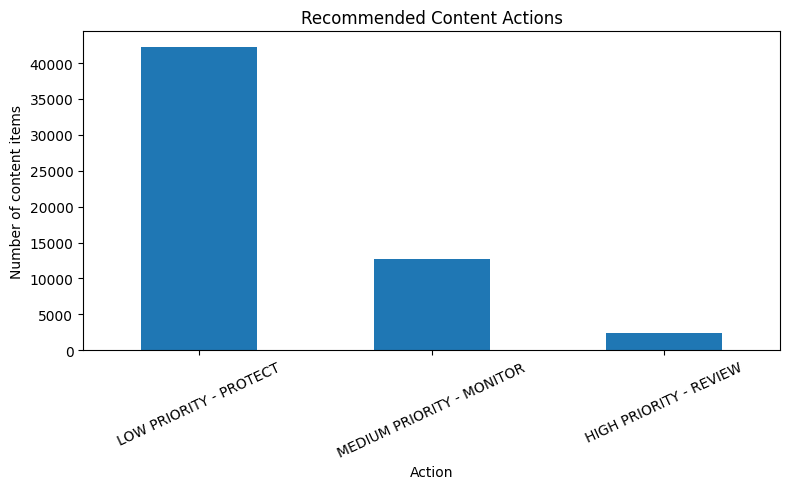

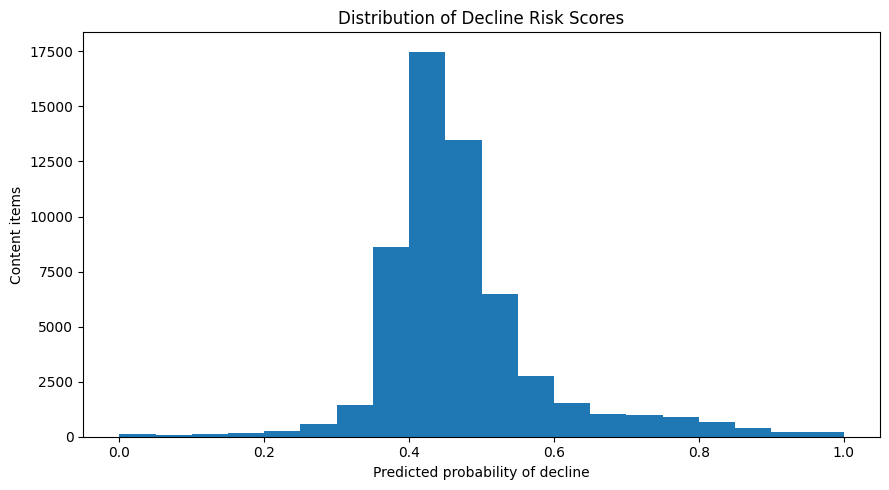

In [ ]:
display(recommendations["action"].value_counts().to_frame("content_count"))
recommendations["action"].value_counts().to_csv("capstone_recommendation_distribution.csv", header=["content_count"])

plt.figure(figsize=(8, 5))
recommendations["action"].value_counts().plot(kind="bar")
plt.title("Recommended Content Actions")
plt.xlabel("Action")
plt.ylabel("Number of content items")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig("capstone_recommended_content_actions.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(recommendations["decline_probability"], bins=20)
plt.xlabel("Predicted probability of decline")
plt.ylabel("Content items")
plt.title("Distribution of Decline Risk Scores")
plt.tight_layout()
plt.savefig("capstone_decline_risk_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


## 15. Sensitivity analysis

In [ ]:
sensitivity_rows = []

for threshold in [-0.10, -0.20, -0.30]:
    y_tr = (train["organic_change"] <= threshold).astype(int)
    y_te = (test["organic_change"] <= threshold).astype(int)

    m = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=2000, class_weight="balanced", random_state=42
        ))
    ])

    m.fit(train[features], y_tr)
    p = m.predict_proba(test[features])[:, 1]
    pred = (p >= 0.50).astype(int)

    sensitivity_rows.append({
        "decline_threshold": threshold,
        "test_positive_rate": y_te.mean(),
        "precision": precision_score(y_te, pred, zero_division=0),
        "recall": recall_score(y_te, pred, zero_division=0),
        "f1": f1_score(y_te, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_te, p)
    })

sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.to_csv("capstone_sensitivity.csv", index=False)
display(sensitivity.round(4))

sensitivity_plot = sensitivity.set_index("decline_threshold")[["precision", "recall", "f1", "roc_auc"]]
sensitivity_plot.plot(kind="line", marker="o", figsize=(9, 5))
plt.title("Sensitivity of Test Metrics to Decline Threshold")
plt.xlabel("Decline threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("capstone_sensitivity_analysis.png", dpi=200, bbox_inches="tight")
plt.show()


,decline_threshold,test_positive_rate,precision,recall,f1,roc_auc
0,-0.1,0.4979,0.5687,0.2987,0.3917,0.5574
1,-0.2,0.4474,0.4967,0.2927,0.3684,0.5409
2,-0.3,0.3989,0.4306,0.2813,0.3403,0.5283


## 16. Export paper-ready artifacts

In [ ]:
top20.to_csv("capstone_ranked_recommendations.csv", index=False)
recommendations.to_csv("capstone_all_recommendations.csv", index=False)
results.to_csv("capstone_model_results.csv", index=False)
importance.to_csv("capstone_feature_importance.csv", index=False)
sensitivity.to_csv("capstone_sensitivity.csv", index=False)

summary = pd.DataFrame({
    "metric": [
        "source_daily_rows", "content_month_rows", "model_rows",
        "train_rows", "validation_rows", "test_rows",
        "test_decline_rate", "test_precision", "test_recall",
        "test_f1", "test_roc_auc", "test_average_precision"
    ],
    "value": [
        int(con.sql(f"SELECT COUNT(*) FROM read_parquet('{PERFORMANCE_GLOB}')").fetchone()[0]),
        len(monthly), len(model_df), len(train), len(validation), len(test),
        float(y_test.mean()), float(model_test["precision"]),
        float(model_test["recall"]), float(model_test["f1"]),
        float(model_test["roc_auc"]), float(ap)
    ]
})

summary.to_csv("capstone_summary.csv", index=False)
display(summary)

print("Saved result tables and figures:")
for artifact in [
    "capstone_monthly_summary.csv",
    "capstone_model_results.csv",
    "capstone_summary.csv",
    "capstone_feature_importance.csv",
    "capstone_ranked_recommendations.csv",
    "capstone_all_recommendations.csv",
    "capstone_recommendation_distribution.csv",
    "capstone_sensitivity.csv",
    "capstone_confusion_matrix.csv",
    "capstone_monthly_organic_sessions.png",
    "capstone_ctr_vs_average_position.png",
    "capstone_feature_importance.png",
    "capstone_recommended_content_actions.png",
    "capstone_decline_risk_distribution.png",
    "capstone_sensitivity_analysis.png",
    "capstone_confusion_matrix.png",
    "capstone_test_diagnostic_curves.png"
]:
    print(artifact)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,metric,value
0,source_daily_rows,7.883566e+07
1,content_month_rows,2.871202e+06
2,model_rows,9.769200e+04
3,train_rows,1.962100e+04
4,validation_rows,2.061300e+04
5,test_rows,5.745800e+04
6,test_decline_rate,4.474399e-01
7,test_precision,4.967001e-01
8,test_recall,2.927380e-01
9,test_f1,3.683708e-01


# 17. Interpretation guardrails

Use only the executed numbers in the final paper.

**Observed:** model performance on the fixed chronological test period.

**Directional:** historical signals associated with higher/lower predicted decline risk.

**Decision-support:** a ranked list for human review.

**Not claimed:** causality, proof of Google's ranking algorithm, or proof that refreshing content causes recovery.

# 18. Final completion checklist

- Run every cell from top to bottom.
- Verify actual month coverage.
- Confirm the leakage audit passes.
- Compare baseline and model on the same test split.
- Record actual metrics and charts.
- Include sensitivity analysis.
- Use anonymized IDs only in public outputs.
- Build the deployed paper from the executed results.
- Put exactly one deployed URL in `submission/paper_url.txt`.
- Include the confusion matrix, ROC curve, and precision-recall curve in the results section.


# 19. Capstone research-paper suitability

**Assessment: suitable with stated limitations.** The workflow is appropriate for a capstone predictive analytics study because it has a defined research question, an auditable content-month unit of analysis, explicit lagged feature engineering, a forward-looking binary target, a chronological train/validation/test design, leakage assertions, a no-decline baseline, multiple classification metrics, ranking logic, and threshold sensitivity analysis.

For the paper, report the following items from the executed notebook: dataset source and monthly coverage; inclusion filters; feature definitions; target threshold (`-20%`); split dates and row counts; leakage-audit result; baseline and logistic-regression results; confusion matrix; ROC and precision-recall curves; feature coefficients; recommendation thresholds; sensitivity results; and exported artifact names.

The conclusions should remain predictive and decision-support oriented. The model identifies content with higher estimated risk of decline; it does not establish causation, prove that a refresh will recover traffic, or represent Google's ranking algorithm. The main residual risks are the anonymized observational data, the single source dataset, possible class imbalance, the fixed 0.50 decision threshold, and limited temporal coverage. Discuss these as limitations and validate the approach on a later holdout period or another dataset if available.
